# Notebook 13 -- Cross-Sectional Sector Alpha

> *Does true sector-level alpha exist beyond market beta in the Thai SET?*

**Architecture:**
- **7 SET sectors:** BANK, ENERGY, ICT, COMMERCE, HEALTH, PROPERTY, FOOD
- **Target:** cross-sectional excess return (sector − market mean)
- **Models:** XGBoost Regressor + XGBoost Ranker (`rank:pairwise`)
- **Signal:** Long top-2 / Short bottom-2 → market-neutral
- **Benchmark:** Equal-weight all-sector portfolio

| Section | Description |
|---|---|
| 1. Data | Sector returns + macro features |
| 2. Features | Sector momentum, vol, macro, regime |
| 3. Target | Cross-sectional demeaning |
| 4. Models | XGB Regressor vs Ranker (walk-forward) |
| 5. Signal | Rank → Long/Short portfolio |
| 6. Backtest | PnL, IC, Sharpe, drawdown, TC |
| 7. Attribution | Feature importance, regime breakdown |
| 8. Verdict | Is sector alpha real? |


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, ttest_1samp
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, XGBRanker
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

SECTORS = ['BANK','ENERGY','ICT','COMMERCE','HEALTH','PROPERTY','FOOD']
TC      = 0.001   # 0.1% one-way TC
MIN_TRAIN = 156   # 3 years
FOLD_SIZE  = 52   # 1 year
LONG_K  = 2       # top-k sectors to go long
SHORT_K = 2       # bottom-k sectors to go short

print('Setup complete.')

Setup complete.


---
## Section 1 -- Data Loading & Merging


In [2]:
# Load sector returns
sector_raw = pd.read_csv(PROC / 'sector_weekly.csv', index_col=0, parse_dates=True)
sector_raw = sector_raw[SECTORS]  # keep only our 7 sectors
print(f'Sector data: {sector_raw.shape[0]} weeks x {sector_raw.shape[1]} sectors')
print(f'Date range: {sector_raw.index[0].date()} -> {sector_raw.index[-1].date()}')

# Load macro features from clean pipeline
macro = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)

# Select macro features (no lookahead, available at t)
MACRO_FEATS = [
    'sp500_ret_w', 'sp500_rvol_4w', 'sp500_ret_d_lag1',
    'eem_ret_d_lag1', 'oil_ret_w', 'oil_ret_d_lag1',
    'gold_ret_w', 'gold_rvol_4w',
    'dxy_ret_w', 'dxy_ret_d_lag1',
    'us_10yr_treasury_ret_w', 'us_2yr_treasury_ret_w',
    'vix_z', 'regime', 'yield_curve_slope',
    'SET_index_ret_w', 'SET_index_rvol_4w',
]
MACRO_FEATS = [f for f in MACRO_FEATS if f in macro.columns]
macro_feats = macro[MACRO_FEATS].copy()
print(f'Macro features: {len(MACRO_FEATS)}')

# Align dates: both indexed to Friday close
sector_raw.index = sector_raw.index.normalize()
macro_feats.index = macro_feats.index.normalize()
common_dates = sector_raw.index.intersection(macro_feats.index)
sector = sector_raw.loc[common_dates]
macro_feats = macro_feats.loc[common_dates]
print(f'Common dates: {len(common_dates)} weeks')
print(f'  {common_dates[0].date()} -> {common_dates[-1].date()}')

Sector data: 1356 weeks x 7 sectors
Date range: 2000-01-14 -> 2026-01-02
Macro features: 17
Common dates: 1322 weeks
  2000-09-01 -> 2025-12-26


---
## Section 2 -- Feature Engineering (Panel)

For each (date, sector) pair, we compute sector-specific features:
- **Momentum**: 1w, 4w, 12w, 26w lagged returns (each sector's own past)
- **Reversal**: 1w return (short-term reversal effect)
- **Realized vol**: rolling std of past 4w returns
- **Relative momentum**: sector momentum vs. cross-sectional median
- **Rank features**: cross-sectional rank of each feature
Plus macro features (same for all sectors each date).


In [3]:
def build_panel(sector_df, macro_df):
    """Build (date × sector) panel with all features. Returns long-format DataFrame."""
    records = []

    # Pre-compute sector-level features (wide format, then melt)
    # Momentum lags (using shift to avoid lookahead)
    mom1  = sector_df.shift(1)           # lag-1w return
    mom4  = sector_df.shift(1).rolling(4).mean()   # 4w mean return (lagged)
    mom12 = sector_df.shift(1).rolling(12).mean()  # 12w
    mom26 = sector_df.shift(1).rolling(26).mean()  # 26w
    rvol4 = sector_df.shift(1).rolling(4).std()    # 4w realized vol
    rvol12= sector_df.shift(1).rolling(12).std()   # 12w vol

    # Cross-sectional rank of momentum (within each date)
    mom1_rank  = mom1.rank(axis=1, pct=True) - 0.5   # -0.5 to +0.5
    mom4_rank  = mom4.rank(axis=1, pct=True) - 0.5
    mom12_rank = mom12.rank(axis=1, pct=True) - 0.5

    # Relative momentum: sector - cross-sectional median
    mom1_rel  = mom1.subtract(mom1.median(axis=1), axis=0)
    mom4_rel  = mom4.subtract(mom4.median(axis=1), axis=0)

    # Forward return (target, shift -1 to get next week's return)
    fwd_ret = sector_df.shift(-1)   # next week's return

    dates = sector_df.index
    for date in dates:
        if date not in macro_df.index:
            continue
        macro_row = macro_df.loc[date]
        # Cross-sectional market return (equal-weight average of sectors)
        market_ret_fwd = fwd_ret.loc[date].mean(skipna=True)

        for sec in sector_df.columns:
            row = {
                'date':   date,
                'sector': sec,
                # Target: next week's cross-sectional excess return
                'fwd_ret':         fwd_ret.loc[date, sec],
                'fwd_excess':      fwd_ret.loc[date, sec] - market_ret_fwd,
                # Sector features
                'mom1':            mom1.loc[date, sec],
                'mom4':            mom4.loc[date, sec],
                'mom12':           mom12.loc[date, sec],
                'mom26':           mom26.loc[date, sec],
                'rvol4':           rvol4.loc[date, sec],
                'rvol12':          rvol12.loc[date, sec],
                'mom1_rank':       mom1_rank.loc[date, sec],
                'mom4_rank':       mom4_rank.loc[date, sec],
                'mom12_rank':      mom12_rank.loc[date, sec],
                'mom1_rel':        mom1_rel.loc[date, sec],
                'mom4_rel':        mom4_rel.loc[date, sec],
            }
            # Add macro features
            for col in macro_df.columns:
                row[col] = macro_row[col] if col in macro_row.index else np.nan
            records.append(row)

    panel = pd.DataFrame(records)
    panel['date'] = pd.to_datetime(panel['date'])
    panel = panel.sort_values(['date','sector']).reset_index(drop=True)
    return panel

print('Building feature panel...')
panel = build_panel(sector, macro_feats)
print(f'Panel shape: {panel.shape}')
print(f'  Rows: {len(panel)} ({len(panel)//len(SECTORS)} dates x {len(SECTORS)} sectors)')
print(f'  Columns: {list(panel.columns[:8])} ... + {len(panel.columns)-8} more')

Building feature panel...


Panel shape: (9254, 32)
  Rows: 9254 (1322 dates x 7 sectors)
  Columns: ['date', 'sector', 'fwd_ret', 'fwd_excess', 'mom1', 'mom4', 'mom12', 'mom26'] ... + 24 more


---
## Section 3 -- Cross-Sectional Target & Feature List


In [4]:
TARGET = 'fwd_excess'   # cross-sectional excess return

SECTOR_FEATS = [
    'mom1', 'mom4', 'mom12', 'mom26',
    'rvol4', 'rvol12',
    'mom1_rank', 'mom4_rank', 'mom12_rank',
    'mom1_rel', 'mom4_rel',
]
ALL_FEATS = SECTOR_FEATS + MACRO_FEATS
ALL_FEATS = [f for f in ALL_FEATS if f in panel.columns]

# Drop rows with no target
panel_clean = panel.dropna(subset=[TARGET]).copy()
dates_all = sorted(panel_clean['date'].unique())
print(f'Clean panel: {len(panel_clean)} rows, {len(dates_all)} dates')
print(f'Features: {len(ALL_FEATS)}')
print(f'  Sector-specific: {len(SECTOR_FEATS)}')
print(f'  Macro:           {len(MACRO_FEATS)}')

# Show target distribution
print(f'\nTarget ({TARGET}) stats:')
print(f'  Mean:  {panel_clean[TARGET].mean():.5f}  (should be ~0 by construction)')
print(f'  Std:   {panel_clean[TARGET].std():.4f}')
print(f'  Range: [{panel_clean[TARGET].min():.3f}, {panel_clean[TARGET].max():.3f}]')

Clean panel: 9247 rows, 1321 dates
Features: 28
  Sector-specific: 11
  Macro:           17

Target (fwd_excess) stats:
  Mean:  -0.00000  (should be ~0 by construction)
  Std:   0.0600
  Range: [-0.880, 4.808]


---
## Section 4 -- Walk-Forward Validation

**Expanding window:** train on all data up to fold start, test on next 52 weeks.  
**Two models per fold:**
- `XGB-Reg`: standard regressor trained on cross-sectional excess return
- `XGB-Rank`: pairwise ranker — directly optimises ranking within each date group

Both models are fitted separately each fold (no parameter leakage).


In [5]:
def make_xgb_reg():
    return XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.6,
        min_child_weight=10, reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, verbosity=0, n_jobs=1
    )

def make_xgb_rank():
    return XGBRanker(
        objective='rank:pairwise',
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.6,
        min_child_weight=5, reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, verbosity=0, n_jobs=1
    )

def walk_forward_sector(panel_df, features, target, min_train_dates,
                         fold_dates, long_k=2, short_k=2):
    """
    Walk-forward cross-sectional backtest.
    Returns per-week portfolio returns for XGB-Reg and XGB-Rank.
    """
    dates = sorted(panel_df['date'].unique())
    n_dates = len(dates)
    t = min_train_dates
    records = []

    while t + fold_dates <= n_dates:
        train_dates = dates[:t]
        test_dates  = dates[t:t+fold_dates]

        train = panel_df[panel_df['date'].isin(train_dates)].copy()
        test  = panel_df[panel_df['date'].isin(test_dates)].copy()

        # Impute with training medians
        medians = train[features].median()
        Xtr = train[features].fillna(medians).fillna(0.).values.astype(float)
        ytr = train[target].values

        # XGB-Reg: standard regressor
        reg = make_xgb_reg()
        reg.fit(Xtr, ytr)

        # XGB-Rank: pairwise ranker — needs group sizes (7 per date)
        train_groups = train.groupby('date').size().values
        rank = make_xgb_rank()
        rank.fit(Xtr, ytr, group=train_groups)

        # Predict and generate signals per test date
        for date in test_dates:
            dt = test[test['date'] == date].copy()
            if len(dt) < 3:   # need at least 3 sectors
                continue
            Xte = dt[features].fillna(medians).fillna(0.).values.astype(float)

            dt = dt.copy()
            dt['pred_reg']  = reg.predict(Xte)
            dt['pred_rank'] = rank.predict(Xte)

            mkt_ret = dt['fwd_ret'].mean()   # equal-weight market return

            for model_name, pred_col in [('reg','pred_reg'),('rank','pred_rank')]:
                dt_s = dt.sort_values(pred_col, ascending=False)
                longs  = dt_s.head(long_k)['sector'].tolist()
                shorts = dt_s.tail(short_k)['sector'].tolist()

                long_ret  = dt_s.head(long_k)['fwd_ret'].mean()
                short_ret = dt_s.tail(short_k)['fwd_ret'].mean()
                port_ret  = (long_ret - short_ret) / 2   # L/S equal weight
                excess    = dt_s.head(long_k)['fwd_excess'].mean() - \
                            dt_s.tail(short_k)['fwd_excess'].mean()

                # IC for this date (rank corr prediction vs actual excess)
                ic_date = float(spearmanr(dt[pred_col], dt['fwd_excess'])[0]) \
                          if len(dt) >= 4 else np.nan

                records.append({
                    'date':       date,
                    'model':      model_name,
                    'port_ret':   port_ret,
                    'excess_ret': excess,
                    'long_ret':   long_ret,
                    'short_ret':  short_ret,
                    'mkt_ret':    mkt_ret,
                    'ic':         ic_date,
                    'longs':  str(longs),
                    'shorts': str(shorts),
                })
        t += fold_dates

    return pd.DataFrame(records)

print(f'Starting walk-forward: {MIN_TRAIN} train dates, {FOLD_SIZE}-date folds...')
wf_results = walk_forward_sector(
    panel_clean, ALL_FEATS, TARGET,
    min_train_dates=MIN_TRAIN, fold_dates=FOLD_SIZE,
    long_k=LONG_K, short_k=SHORT_K
)

# Split by model
res_reg  = wf_results[wf_results['model']=='reg'].set_index('date').sort_index()
res_rank = wf_results[wf_results['model']=='rank'].set_index('date').sort_index()

print(f'Walk-forward complete: {len(res_reg)} OOS weeks per model')
print(f'Date range: {res_reg.index[0].date()} -> {res_reg.index[-1].date()}')

Starting walk-forward: 156 train dates, 52-date folds...


Walk-forward complete: 1144 OOS weeks per model
Date range: 2003-08-29 -> 2025-07-25


---
## Section 5 -- Information Coefficient Analysis

IC = Spearman rank correlation between predicted scores and actual excess returns,  
computed cross-sectionally within each week.  
`ICIR = mean(IC) / std(IC) × √n_weeks` — higher = more consistent signal.


IC Analysis
XGB-Regressor:
  IC mean:  +0.0262
  IC std:   0.4190
  ICIR:     +2.118
  IC > 0:   51.1% of weeks
  t-stat:   +2.118  (p=0.0343)

XGB-Ranker:
  IC mean:  +0.0094
  IC std:   0.4161
  ICIR:     +0.760
  IC > 0:   49.5% of weeks
  t-stat:   +0.760  (p=0.4474)


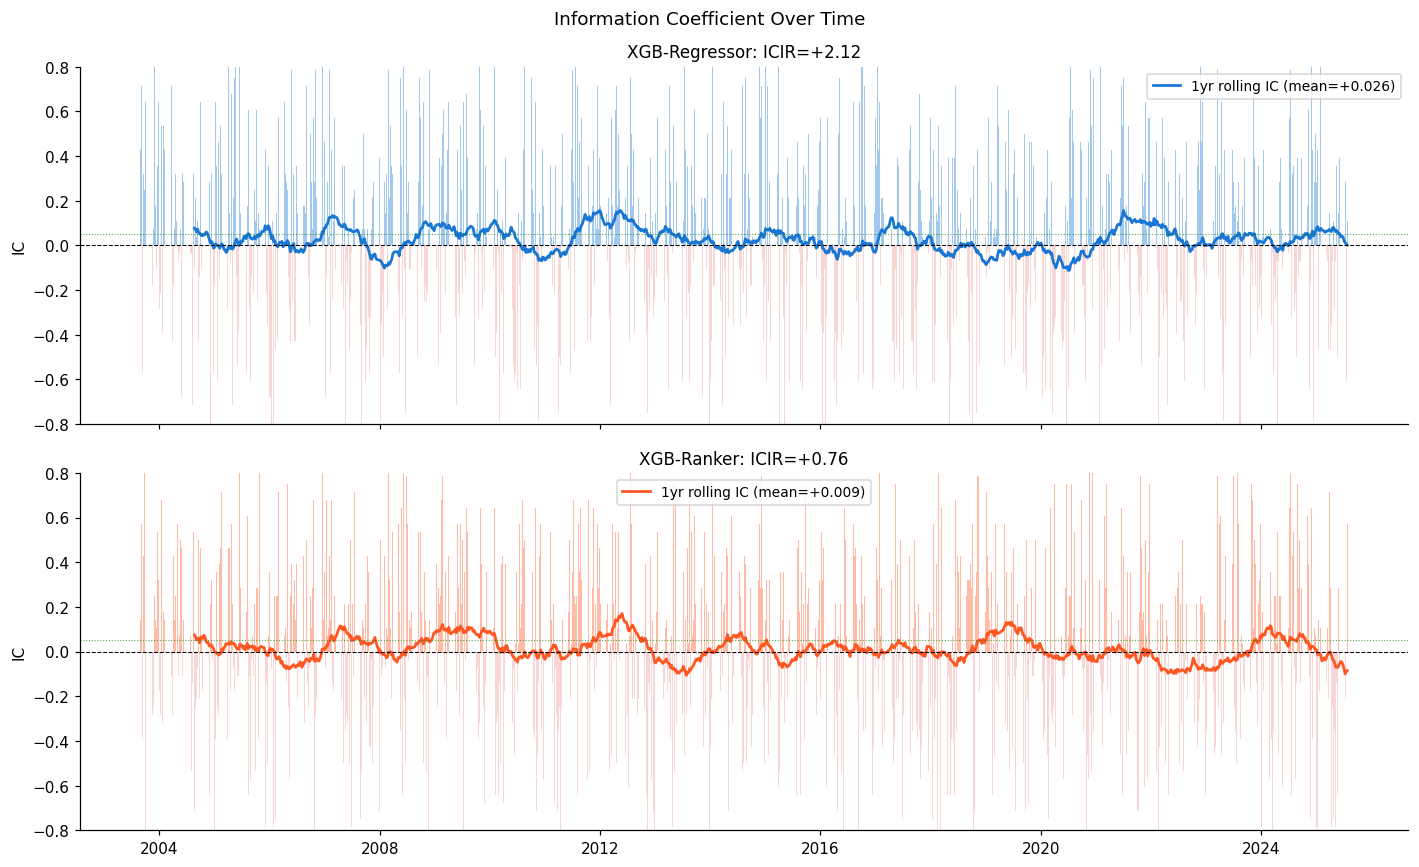

Saved: figs/sector_ic.png


In [6]:
def ic_summary(results_df, label):
    ics = results_df['ic'].dropna()
    t_stat, p_val = ttest_1samp(ics, 0) if len(ics) >= 10 else (np.nan, np.nan)
    icir = ics.mean() / ics.std() * np.sqrt(len(ics)) if ics.std() > 0 else np.nan
    print(f'{label}:')
    print(f'  IC mean:  {ics.mean():+.4f}')
    print(f'  IC std:   {ics.std():.4f}')
    print(f'  ICIR:     {icir:+.3f}')
    print(f'  IC > 0:   {(ics>0).mean():.1%} of weeks')
    print(f'  t-stat:   {t_stat:+.3f}  (p={p_val:.4f})')
    return {'ic_mean':ics.mean(),'icir':icir,'ic_pos':( ics>0).mean(),'p':p_val}

print('IC Analysis\n' + '='*50)
ic_reg  = ic_summary(res_reg,  'XGB-Regressor')
print()
ic_rank = ic_summary(res_rank, 'XGB-Ranker')

# Rolling IC plot
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Information Coefficient Over Time', fontsize=12)

for ax, (res, lbl, col) in zip(axes, [
    (res_reg,  'XGB-Regressor', '#1976D2'),
    (res_rank, 'XGB-Ranker',    '#FF5722'),
]):
    ic_ser = res['ic'].dropna()
    roll_ic = ic_ser.rolling(52).mean()
    ax.bar(ic_ser.index, ic_ser, color=[col if x>0 else '#EF9A9A' for x in ic_ser],
           alpha=0.4, width=5)
    ax.plot(roll_ic.index, roll_ic, color=col, lw=1.8,
            label=f'1yr rolling IC (mean={ic_ser.mean():+.3f})')
    ax.axhline(0, color='black', lw=0.7, ls='--')
    ax.axhline(0.05, color='green', lw=0.7, ls=':', alpha=0.7)
    ax.set_ylabel('IC')
    ax.set_title(f'{lbl}: ICIR={ic_ser.mean()/ic_ser.std()*np.sqrt(len(ic_ser)):+.2f}')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.8, 0.8)

plt.tight_layout()
plt.savefig(FIGS / 'sector_ic.png', bbox_inches='tight')
plt.show()
print('Saved: figs/sector_ic.png')

---
## Section 6 -- Backtesting: PnL, Sharpe, Drawdown


In [7]:
def apply_tc(ret_series, tc=TC):
    """Apply 2×TC cost on position flips (simplified: assume 50% turnover/week for L/S)."""
    # Each rebalance: exit 2 longs + 2 shorts, enter 2 new longs + 2 new shorts
    # Turnover ≈ fraction of positions that change each week
    # Conservative: charge TC every week (full rebalance)
    return ret_series - 4 * tc   # 4 positions × TC each week

def risk_metrics(rets, freq=52, label=''):
    r = pd.Series(rets).dropna()
    if len(r) < 10: return {}
    ann_ret = (1+r).prod()**(freq/len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = (1 + r).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'ann_ret':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
            'max_dd':max_dd,'win_rate':(r>0).mean(),'n':len(r)}

# Benchmark: equal-weight all sectors (market return)
bnh = res_reg['mkt_ret']   # equal-weight market

# Apply TC
reg_gross  = res_reg['port_ret']
reg_net    = apply_tc(reg_gross)
rank_gross = res_rank['port_ret']
rank_net   = apply_tc(rank_gross)

# Compute metrics
print(f'{"Strategy":<25} {"AnnRet":>8} {"AnnVol":>8} {"Sharpe":>8} {"MaxDD":>8} {"WinRate":>8}')
print('-' * 70)
for rets, lbl in [
    (reg_gross,  'XGB-Reg  (gross)'),
    (reg_net,    'XGB-Reg  (net TC)'),
    (rank_gross, 'XGB-Rank (gross)'),
    (rank_net,   'XGB-Rank (net TC)'),
    (bnh,        'Equal-Weight BnH'),
]:
    m = risk_metrics(rets)
    print(f'{lbl:<25} {m["ann_ret"]:>8.2%} {m["ann_vol"]:>8.2%} '
          f'{m["sharpe"]:>8.2f} {m["max_dd"]:>8.1%} {m["win_rate"]:>8.1%}')

Strategy                    AnnRet   AnnVol   Sharpe    MaxDD  WinRate
----------------------------------------------------------------------
XGB-Reg  (gross)             2.67%    9.46%     0.28   -20.8%    51.7%
XGB-Reg  (net TC)          -16.64%    9.46%    -1.76   -98.3%    36.8%
XGB-Rank (gross)             0.15%    9.70%     0.01   -46.2%    48.5%
XGB-Rank (net TC)          -18.70%    9.70%    -1.93   -99.0%    35.2%
Equal-Weight BnH            17.57%   25.17%     0.70   -53.5%    58.0%


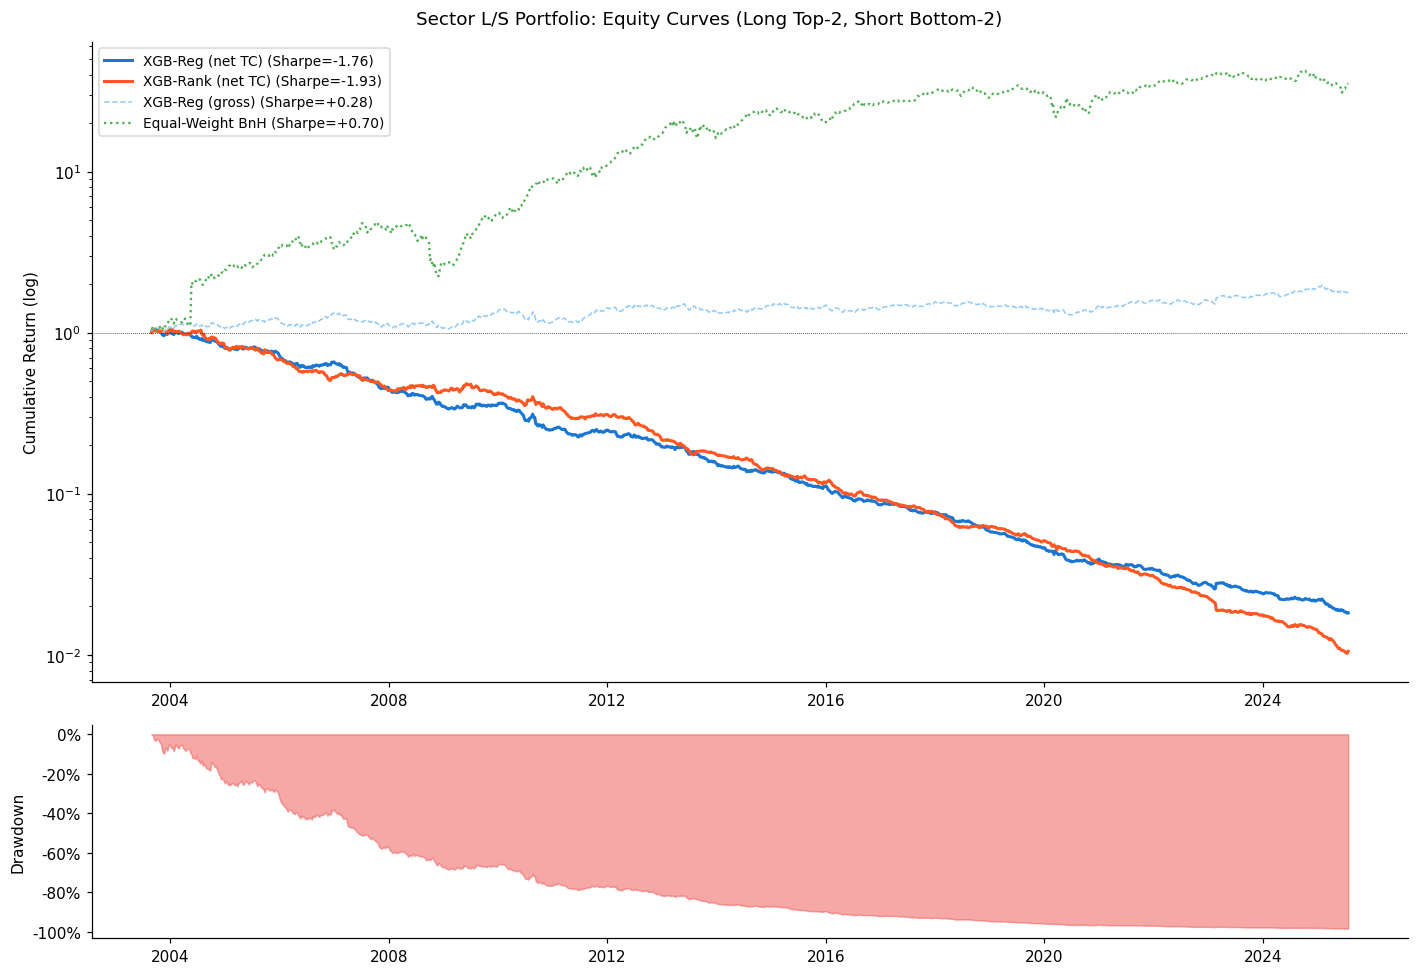

Saved: figs/sector_equity.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('Sector L/S Portfolio: Equity Curves (Long Top-2, Short Bottom-2)', fontsize=12)

ax = axes[0]
for rets, lbl, col, lw, ls in [
    (reg_net,   'XGB-Reg (net TC)',  '#1976D2', 2.0, '-'),
    (rank_net,  'XGB-Rank (net TC)', '#FF5722', 2.0, '-'),
    (reg_gross, 'XGB-Reg (gross)',   '#90CAF9', 1.0, '--'),
    (bnh,       'Equal-Weight BnH',  '#4CAF50', 1.5, ':'),
]:
    cum = (1 + rets.reindex(res_reg.index)).cumprod()
    m   = risk_metrics(rets)
    ax.plot(cum.index, cum, lw=lw, ls=ls, color=col,
            label=f'{lbl} (Sharpe={m["sharpe"]:+.2f})')
ax.axhline(1.0, color='black', lw=0.5, ls=':')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log)')
ax.legend(fontsize=9, loc='upper left')

# Drawdown of best model
best_ret = rank_net if risk_metrics(rank_net)['sharpe'] > risk_metrics(reg_net)['sharpe'] \
           else reg_net
cum_best = (1 + best_ret.reindex(res_reg.index)).cumprod()
dd = (cum_best - cum_best.cummax()) / cum_best.cummax()
axes[1].fill_between(dd.index, dd, 0, color='#EF5350', alpha=0.5)
axes[1].set_ylabel('Drawdown')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

plt.tight_layout()
plt.savefig(FIGS / 'sector_equity.png', bbox_inches='tight')
plt.show()
print('Saved: figs/sector_equity.png')

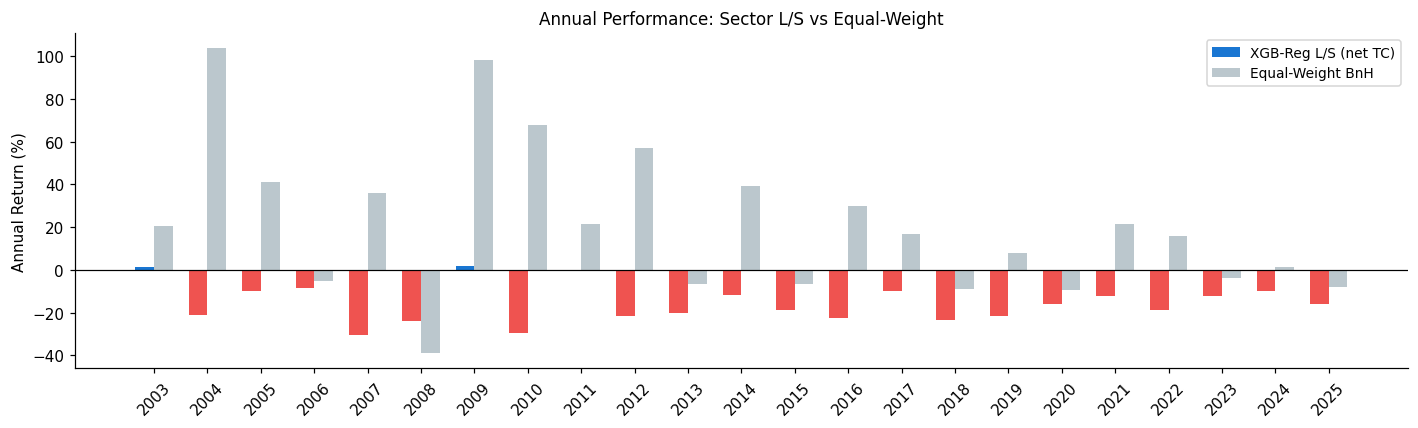

  Year    XGB-Reg   EW-BnH
----------------------------
  2003      1.3% ✓    20.6%
  2004    -21.1% ✗   103.6%
  2005     -9.7% ✗    41.0%
  2006     -8.6% ✗    -5.4%
  2007    -30.5% ✗    36.0%
  2008    -24.0% ✗   -39.0%
  2009      1.7% ✓    98.3%
  2010    -29.4% ✗    68.0%
  2011     -0.3% ✗    21.3%
  2012    -21.6% ✗    57.1%
  2013    -20.4% ✗    -6.6%
  2014    -11.8% ✗    39.2%
  2015    -19.0% ✗    -6.7%
  2016    -22.8% ✗    29.7%
  2017     -9.9% ✗    16.6%
  2018    -23.6% ✗    -8.9%
  2019    -21.8% ✗     7.7%
  2020    -16.2% ✗    -9.7%
  2021    -12.3% ✗    21.6%
  2022    -18.7% ✗    16.0%
  2023    -12.4% ✗    -4.0%
  2024     -9.7% ✗     1.2%
  2025    -16.2% ✗    -8.2%

Positive years: 2/23


In [9]:
# Annual returns
best_net = rank_net if risk_metrics(rank_net)['sharpe'] > risk_metrics(reg_net)['sharpe'] \
           else reg_net
best_lbl = 'XGB-Rank' if risk_metrics(rank_net)['sharpe'] > risk_metrics(reg_net)['sharpe'] \
           else 'XGB-Reg'

annual = pd.DataFrame({
    'signal': best_net.groupby(best_net.index.year).apply(lambda r: (1+r).prod()-1),
    'bnh':    bnh.groupby(bnh.index.year).apply(lambda r: (1+r).prod()-1),
})

fig, ax = plt.subplots(figsize=(13, 4))
x = range(len(annual))
w = 0.35
ax.bar([i-w/2 for i in x], annual['signal']*100, width=w,
       color=['#1976D2' if v>0 else '#EF5350' for v in annual['signal']],
       label=f'{best_lbl} L/S (net TC)')
ax.bar([i+w/2 for i in x], annual['bnh']*100, width=w,
       color='#78909C', alpha=0.5, label='Equal-Weight BnH')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(annual.index, rotation=45)
ax.set_ylabel('Annual Return (%)')
ax.set_title('Annual Performance: Sector L/S vs Equal-Weight')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'sector_annual.png', bbox_inches='tight')
plt.show()

pos_yrs = (annual['signal'] > 0).sum()
print(f'{"Year":>6} {best_lbl[:10]:>10} {"EW-BnH":>8}')
print('-' * 28)
for yr, row in annual.iterrows():
    flag = '✓' if row['signal'] > 0 else '✗'
    print(f'{yr:>6} {row["signal"]:>9.1%} {flag}  {row["bnh"]:>7.1%}')
print(f'\nPositive years: {pos_yrs}/{len(annual)}')

---
## Section 7 -- Feature Importance & Regime Attribution


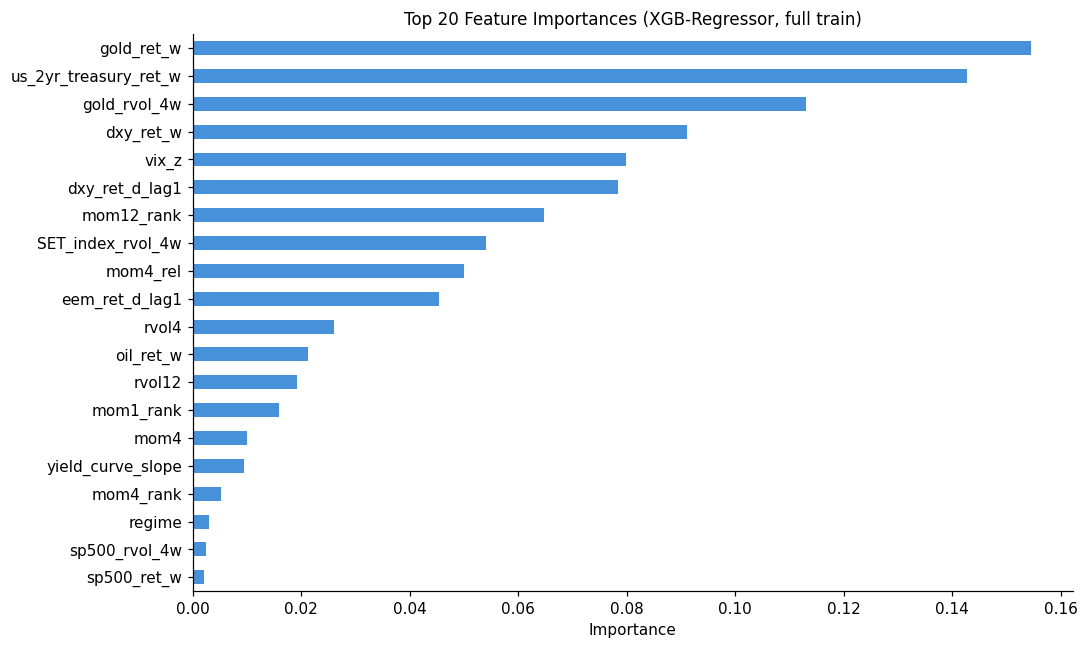

Top 15 features:
  gold_ret_w                     0.1545  [MACRO]
  us_2yr_treasury_ret_w          0.1428  [MACRO]
  gold_rvol_4w                   0.1131  [MACRO]
  dxy_ret_w                      0.0910  [MACRO]
  vix_z                          0.0799  [MACRO]
  dxy_ret_d_lag1                 0.0784  [MACRO]
  mom12_rank                     0.0647  [SECTOR]
  SET_index_rvol_4w              0.0541  [MACRO]
  mom4_rel                       0.0501  [SECTOR]
  eem_ret_d_lag1                 0.0454  [MACRO]
  rvol4                          0.0261  [SECTOR]
  oil_ret_w                      0.0213  [MACRO]
  rvol12                         0.0193  [SECTOR]
  mom1_rank                      0.0159  [SECTOR]
  mom4                           0.0101  [SECTOR]


In [10]:
# Fit final model on full training data (all but last 2 years)
cutoff = sorted(panel_clean['date'].unique())[-104]  # last 2 years = test
train_final = panel_clean[panel_clean['date'] < cutoff]

medians_final = train_final[ALL_FEATS].median()
Xtr_f = train_final[ALL_FEATS].fillna(medians_final).fillna(0.).values.astype(float)
ytr_f = train_final[TARGET].values

reg_final = make_xgb_reg()
reg_final.fit(Xtr_f, ytr_f)

# Feature importance
imp = pd.Series(reg_final.feature_importances_, index=ALL_FEATS)
imp = imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_n = 20
imp.head(top_n).plot(kind='barh', ax=ax, color='#1976D2', alpha=0.8)
ax.invert_yaxis()
ax.set_title(f'Top {top_n} Feature Importances (XGB-Regressor, full train)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIGS / 'sector_importance.png', bbox_inches='tight')
plt.show()

print('Top 15 features:')
for feat, val in imp.head(15).items():
    tag = '  [SECTOR]' if feat in SECTOR_FEATS else '  [MACRO]'
    print(f'  {feat:<30} {val:.4f}{tag}')

In [11]:
# Regime performance
if 'regime' in panel_clean.columns:
    # Get regime per date (mode across sectors, since all same)
    regime_map = panel_clean.groupby('date')['regime'].first()
    regime_labels = {-1: 'Bull (low VIX)', 0: 'Normal', 1: 'Crisis (high VIX)'}

    print(f'{"Regime":<22} {"N":>5} {"AnnRet(signal)":>16} {"Sharpe":>8} {"IC mean":>8}')
    print('-' * 62)
    for r, lbl in sorted(regime_labels.items()):
        dates_r = regime_map[regime_map == r].index
        rets_r  = best_net.reindex(dates_r).dropna()
        ics_r   = res_rank.loc[res_rank.index.isin(dates_r), 'ic'].dropna()
        if len(rets_r) < 5:
            print(f'{lbl:<22} -- insufficient')
            continue
        m = risk_metrics(rets_r)
        print(f'{lbl:<22} {len(rets_r):>5} {m["ann_ret"]:>16.1%} '
              f'{m["sharpe"]:>8.2f} {ics_r.mean():>+8.3f}')
else:
    print('Regime column not available — skipping regime breakdown')

Regime                     N   AnnRet(signal)   Sharpe  IC mean
--------------------------------------------------------------
Bull (low VIX)         -- insufficient
Normal                   529           -13.6%    -1.57   +0.016
Crisis (high VIX)        337           -22.6%    -2.40   -0.027


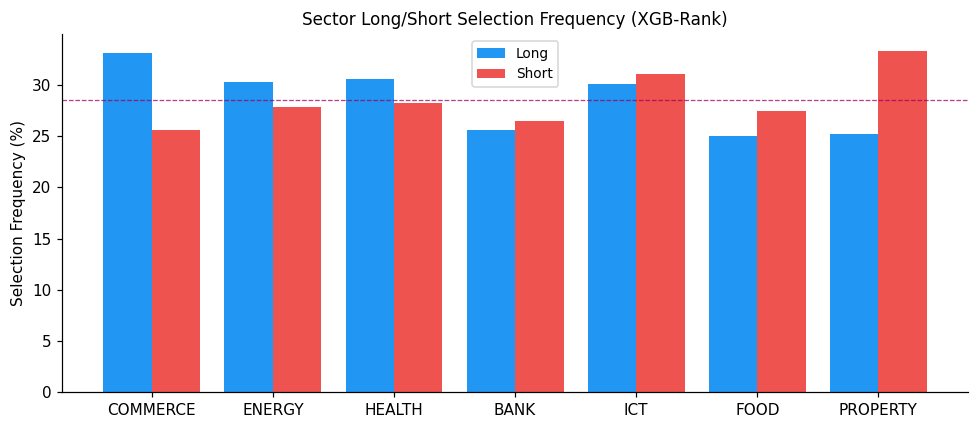

          Long %  Short %    Net
COMMERCE   0.331    0.256  0.075
ENERGY     0.303    0.279  0.024
HEALTH     0.306    0.282  0.024
BANK       0.256    0.265 -0.009
ICT        0.301    0.310 -0.010
FOOD       0.250    0.274 -0.024
PROPERTY   0.253    0.333 -0.080


In [12]:
# Sector selection frequency: which sectors were most often in top/bottom?
from ast import literal_eval

long_counts  = {s: 0 for s in SECTORS}
short_counts = {s: 0 for s in SECTORS}

for _, row in res_rank.iterrows():
    try:
        longs  = literal_eval(row['longs'])
        shorts = literal_eval(row['shorts'])
        for s in longs:  long_counts[s]  = long_counts.get(s, 0) + 1
        for s in shorts: short_counts[s] = short_counts.get(s, 0) + 1
    except:
        pass

n_weeks = len(res_rank)
freq_df = pd.DataFrame({
    'Long %':  {s: long_counts[s]/n_weeks  for s in SECTORS},
    'Short %': {s: short_counts[s]/n_weeks for s in SECTORS},
})
freq_df['Net'] = freq_df['Long %'] - freq_df['Short %']
freq_df = freq_df.sort_values('Net', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(SECTORS))
ax.bar([i-0.2 for i in x], freq_df['Long %']*100,  width=0.4,
       color='#2196F3', label='Long')
ax.bar([i+0.2 for i in x], freq_df['Short %']*100, width=0.4,
       color='#EF5350', label='Short')
ax.axhline(LONG_K/len(SECTORS)*100, color='blue',  lw=0.8, ls='--', alpha=0.5)
ax.axhline(SHORT_K/len(SECTORS)*100, color='red', lw=0.8, ls='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(freq_df.index)
ax.set_ylabel('Selection Frequency (%)')
ax.set_title('Sector Long/Short Selection Frequency (XGB-Rank)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'sector_rotation.png', bbox_inches='tight')
plt.show()

print(freq_df.round(3))

---
## Section 8 -- Final Verdict


In [13]:
m_reg  = risk_metrics(reg_net)
m_rank = risk_metrics(rank_net)
m_bnh  = risk_metrics(bnh)

score = 0
evidence = []
def ev(desc, val, thresh, passes, fmt='f'):
    global score
    if passes: score += 1
    sign = '+' if passes else '-'
    vs = f'{val:.2%}' if fmt=='pct' else f'{val:.3f}'
    evidence.append((sign, desc, vs, thresh))

best_m = m_rank if m_rank['sharpe'] > m_reg['sharpe'] else m_reg
best_ic = ic_rank if ic_rank['ic_mean'] > ic_reg['ic_mean'] else ic_reg

ev('IC mean > 0.05',           best_ic['ic_mean'],   '>0.05', best_ic['ic_mean'] > 0.05)
ev('IC t-test p < 0.05',       best_ic['p'],         '<0.05', best_ic['p'] < 0.05)
ev('ICIR > 0.5',               best_ic['icir'],      '>0.5',  best_ic['icir'] > 0.5)
ev('IC+ fraction > 55%',       best_ic['ic_pos'],    '>55%',  best_ic['ic_pos'] > 0.55, 'pct')
ev('Sharpe (net TC) > 0.5',    best_m['sharpe'],     '>0.5',  best_m['sharpe'] > 0.5)
ev('Sharpe > Equal-Weight',    best_m['sharpe']-m_bnh['sharpe'],
                                '>0',   best_m['sharpe'] > m_bnh['sharpe'])
ev('Annual return (net) > 5%', best_m['ann_ret'],    '>5%',   best_m['ann_ret'] > 0.05, 'pct')
ev('Max DD > -30%',            best_m['max_dd'],     '>-30%', best_m['max_dd'] > -0.30, 'pct')
pos_yr_frac = (annual['signal'] > 0).mean()
ev('Positive years > 60%',     pos_yr_frac,          '>60%',  pos_yr_frac > 0.60, 'pct')

print('=' * 65)
print('SECTOR ALPHA VERDICT')
print('=' * 65)
print(f'{"":>2} {"Evidence":<38} {"Value":>8} {"Threshold":>10}')
print('-' * 62)
for sign, desc, val, thresh in evidence:
    print(f'[{sign}] {desc:<38} {val:>8} {thresh:>10}')
print(f'\nScore: {score}/{len(evidence)}')
print()

if score >= 7:
    verdict = 'REAL SECTOR ALPHA EXISTS'
    detail  = 'IC > 0.05, Sharpe > 0.5 after TC, beats benchmark. '\
              'Sector rotation signal is exploitable.'
elif score >= 5:
    verdict = 'WEAK SECTOR ALPHA'
    detail  = 'Some evidence of sector rotation predictability but '\
              'not strong enough for live trading. Needs more features or data.'
else:
    verdict = 'NO SECTOR ALPHA FOUND'
    detail  = 'Cross-sectional prediction does not generate consistent '\
              'positive IC or Sharpe after TC. Sector rotation not predictable '\
              'with current feature set.'

print('=' * 65)
print(f'VERDICT: {verdict}')
print('=' * 65)
print(f'\n{detail}')
print(f'\nBest model: {best_lbl}')
print(f'  Sharpe (net TC):  {best_m["sharpe"]:+.3f}')
print(f'  Annual return:    {best_m["ann_ret"]:+.2%}')
print(f'  IC mean:          {best_ic["ic_mean"]:+.4f}')

SECTOR ALPHA VERDICT
   Evidence                                  Value  Threshold
--------------------------------------------------------------
[-] IC mean > 0.05                            0.026      >0.05
[+] IC t-test p < 0.05                        0.034      <0.05
[+] ICIR > 0.5                                2.118       >0.5
[-] IC+ fraction > 55%                       51.14%       >55%
[-] Sharpe (net TC) > 0.5                    -1.758       >0.5
[-] Sharpe > Equal-Weight                    -2.456         >0
[-] Annual return (net) > 5%                -16.64%        >5%
[-] Max DD > -30%                           -98.29%      >-30%
[-] Positive years > 60%                      8.70%       >60%

Score: 2/9

VERDICT: NO SECTOR ALPHA FOUND

Cross-sectional prediction does not generate consistent positive IC or Sharpe after TC. Sector rotation not predictable with current feature set.

Best model: XGB-Reg
  Sharpe (net TC):  -1.758
  Annual return:    -16.64%
  IC mean:          